In [3]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import os
print(tf.__version__)

2.20.0


In [4]:
IMG_HEIGHT=150
IMG_WIDTH=150
BATCH_SIZE=32
EPOCHS=15
TRAIN_DIR="dataset/train"
VAL_DIR="dataset/validation"

train_datagen=tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode="nearest"
    )
val_datagen=tf.keras.preprocessing.image.ImageDataGenerator(rescale=1.0/255)

train_generator=train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_HEIGHT,IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode="binary"
)

val_generator=train_datagen.flow_from_directory(
    VAL_DIR,
    target_size=(IMG_HEIGHT,IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode="binary"
)

Found 2000 images belonging to 2 classes.
Found 800 images belonging to 2 classes.


In [18]:
def Baseline_model():
    model = keras.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu',
                      input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
        layers.MaxPooling2D(2, 2),

        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D(2, 2),

        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.MaxPooling2D(2, 2),

        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')
    ])
    return model

model=Baseline_model()
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_22 (Conv2D)              │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,828,481 (18.42 MB)

 Trainable params: 4,828,481 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history=model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator
    )

Epoch 1/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 48s 747ms/step - accuracy: 0.5075 - loss: 0.7052 - val_accuracy: 0.5312 - val_loss: 0.6910
Epoch 2/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 52s 826ms/step - accuracy: 0.5600 - loss: 0.6761 - val_accuracy: 0.5875 - val_loss: 0.6843
Epoch 3/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 54s 856ms/step - accuracy: 0.6035 - loss: 0.6715 - val_accuracy: 0.6400 - val_loss: 0.6553
Epoch 4/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 55s 865ms/step - accuracy: 0.5945 - loss: 0.6695 - val_accuracy: 0.6100 - val_loss: 0.6683
Epoch 5/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 47s 744ms/step - accuracy: 0.6315 - loss: 0.6532 - val_accuracy: 0.6587 - val_loss: 0.6364
Epoch 6/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 41s 643ms/step - accuracy: 0.6675 - loss: 0.6310 - val_accuracy: 0.6263 - val_loss: 0.7039
Epoch 7/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 42s 661ms/step - accuracy: 0.6480 - loss: 0.6320 - val_accuracy: 0.6575 - val_loss: 0.6189
Epoch 8/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 37s 595ms/step - accuracy: 0.6915 - loss: 0.5863 - val_accu

In [7]:
def plot_history(history, title=''):
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    axes[0].plot(history.history['accuracy'], label='train acc')
    axes[0].plot(history.history['val_accuracy'], label='val acc')
    axes[0].set_title(f'Accuracy {title}')
    axes[0].set_xlabel('Epoch')
    axes[0].legend()

    axes[1].plot(history.history['loss'], label='train loss')
    axes[1].plot(history.history['val_loss'], label='val loss')
    axes[1].set_title(f'Loss {title}')
    axes[1].set_xlabel('Epoch')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

plot_history(history, title='(Baseline)')


NameError: name 'history' is not defined

Epoch 1/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 27s 383ms/step - accuracy: 0.5480 - loss: 0.6812 - val_accuracy: 0.6413 - val_loss: 0.6553
Epoch 2/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 22s 354ms/step - accuracy: 0.5945 - loss: 0.6644 - val_accuracy: 0.6562 - val_loss: 0.6278
Epoch 3/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 23s 359ms/step - accuracy: 0.6140 - loss: 0.6531 - val_accuracy: 0.6438 - val_loss: 0.6376
Epoch 4/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 23s 365ms/step - accuracy: 0.6480 - loss: 0.6356 - val_accuracy: 0.6625 - val_loss: 0.6209
Epoch 5/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 23s 364ms/step - accuracy: 0.6720 - loss: 0.6189 - val_accuracy: 0.6988 - val_loss: 0.6095
Epoch 6/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 24s 374ms/step - accuracy: 0.6820 - loss: 0.6061 - val_accuracy: 0.7038 - val_loss: 0.5846
Epoch 7/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 24s 375ms/step - accuracy: 0.6965 - loss: 0.5969 - val_accuracy: 0.6900 - val_loss: 0.5952
Epoch 8/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 36s 580ms/step - accuracy: 0.6855 - loss: 0.5838 - val_accu

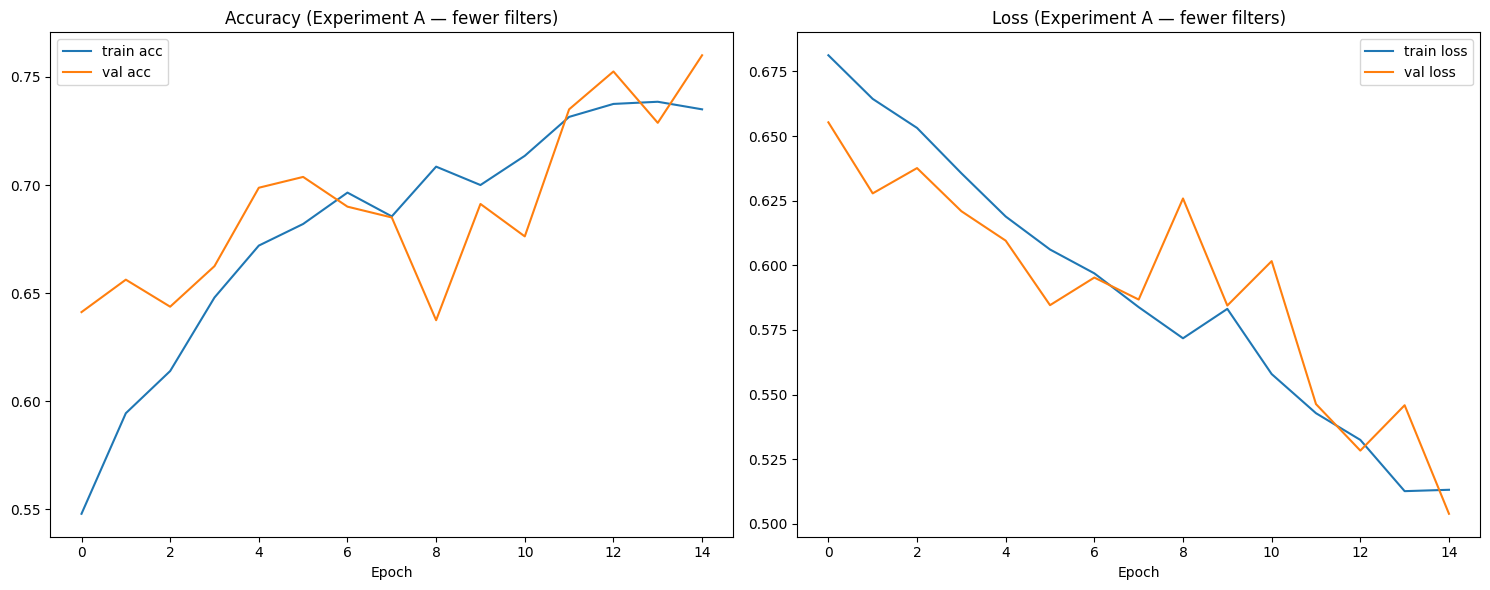

In [16]:
def build_model_A():
    model = keras.Sequential([
        layers.Conv2D(8, (3, 3), activation='relu',
                      input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
        layers.MaxPooling2D(2, 2),

        layers.Conv2D(16, (3, 3), activation='relu'),
        layers.MaxPooling2D(2, 2),

        layers.Conv2D(32, (3, 3), activation='relu'),
        layers.MaxPooling2D(2, 2),

        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')
    ])
    return model

model_A = build_model_A()
model_A.compile(optimizer='adam', loss='binary_crossentropy',
                metrics=['accuracy'])
history_A = model_A.fit(train_generator, epochs=EPOCHS,
                        validation_data=val_generator)
plot_history(history_A, title='(Experiment A — fewer filters)')


c:\Users\dayan\OneDrive\Рабочий стол\deep learning\labs\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 35s 509ms/step - accuracy: 0.5150 - loss: 0.7057 - val_accuracy: 0.5000 - val_loss: 0.6930
Epoch 2/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 26s 420ms/step - accuracy: 0.5315 - loss: 0.6927 - val_accuracy: 0.5600 - val_loss: 0.6859
Epoch 3/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 26s 412ms/step - accuracy: 0.5310 - loss: 0.6901 - val_accuracy: 0.5987 - val_loss: 0.6806
Epoch 4/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 27s 423ms/step - accuracy: 0.5770 - loss: 0.6777 - val_accuracy: 0.6388 - val_loss: 0.6478
Epoch 5/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 26s 412ms/step - accuracy: 0.6180 - loss: 0.6581 - val_accuracy: 0.6288 - val_loss: 0.6543
Epoch 6/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 25s 403ms/step - accuracy: 0.6485 - loss: 0.6453 - val_accuracy: 0.6600 - val_loss: 0.6222
Epoch 7/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 26s 418ms/step - accuracy: 0.6535 - loss: 0.6157 - val_accuracy: 0.6700 - val_loss: 0.6309
Epoch 8/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 26s 419ms/step - accuracy: 0.6630 - loss: 0.6196 - val_accu

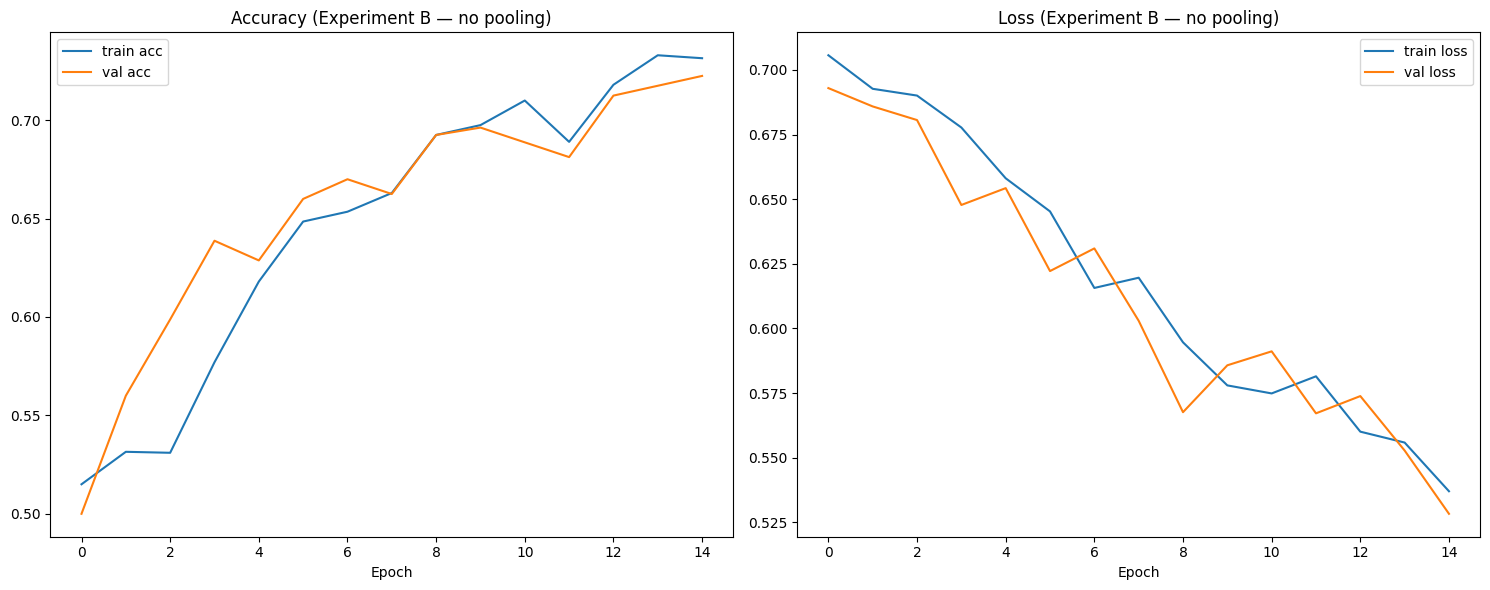

In [15]:
def build_model_B():
    model = keras.Sequential([
        layers.Conv2D(32, (3, 3), strides=2, activation='relu',
                      input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),

        layers.Conv2D(64, (3, 3), strides=2, activation='relu'),

        layers.Conv2D(128, (3, 3), strides=2, activation='relu'),

        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')
    ])
    return model

model_B = build_model_B()
model_B.compile(optimizer='adam', loss='binary_crossentropy',
                metrics=['accuracy'])
history_B = model_B.fit(train_generator, epochs=EPOCHS,
                        validation_data=val_generator)
plot_history(history_B, title='(Experiment B — no pooling)')


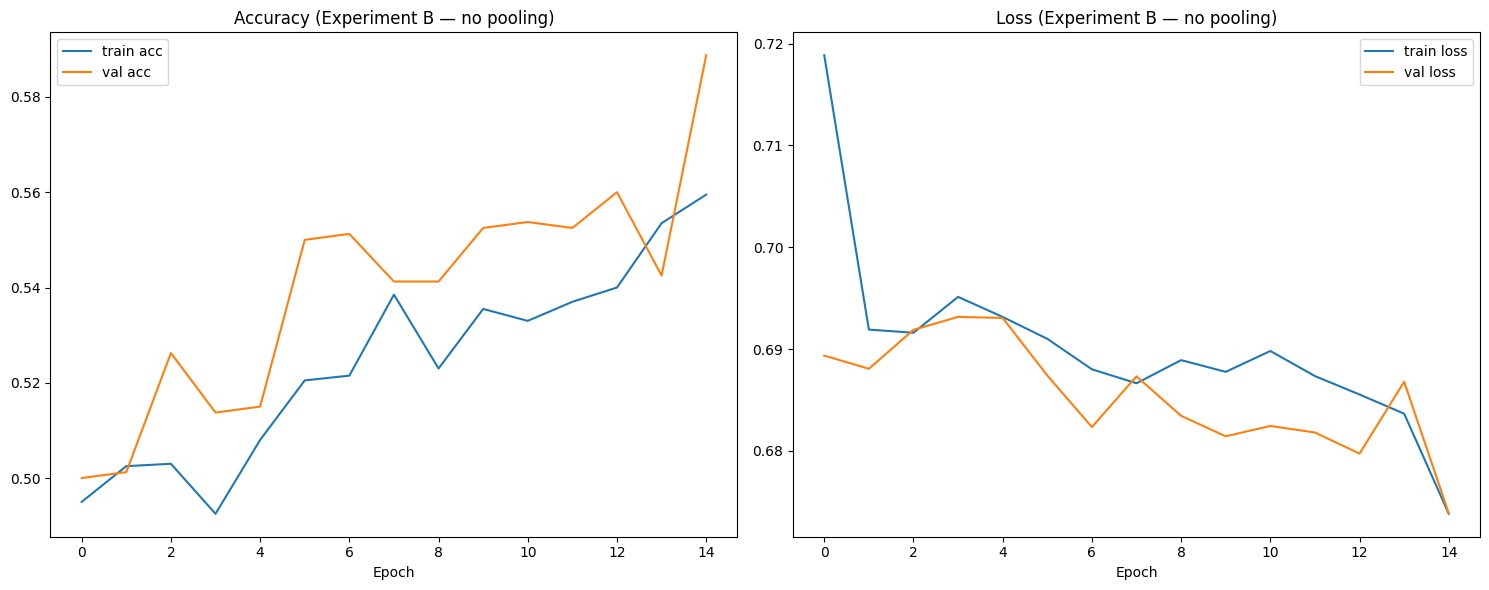

In [9]:
plot_history(history_B, title='(Experiment B — no pooling)')

In [10]:
model_B.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 74, 74, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 36, 36, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 17, 17, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,485,445 (55.26 MB)

 Trainable params: 4,828,481 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 9,656,964 (36.84 MB)

In [20]:
def build_model_C():
    model = keras.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu',
                      input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
        layers.MaxPooling2D(2, 2),

        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D(2, 2),

        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.MaxPooling2D(2, 2),

        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        # No Dropout here!
        layers.Dense(1, activation='sigmoid')
    ])
    return model

model_C = build_model_C()
model_C.compile(optimizer='adam', loss='binary_crossentropy',
                metrics=['accuracy'])
history_C = model_C.fit(train_generator, epochs=EPOCHS,
                        validation_data=val_generator)
plot_history(history_C, title='(Experiment C — no dropout)')

Epoch 1/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 32s 478ms/step - accuracy: 0.5105 - loss: 0.7099 - val_accuracy: 0.5362 - val_loss: 0.6924
Epoch 2/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 30s 481ms/step - accuracy: 0.5350 - loss: 0.6756 - val_accuracy: 0.5850 - val_loss: 0.6638
Epoch 3/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 31s 489ms/step - accuracy: 0.5795 - loss: 0.6624 - val_accuracy: 0.5462 - val_loss: 0.6772
Epoch 4/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 31s 499ms/step - accuracy: 0.6385 - loss: 0.6431 - val_accuracy: 0.6413 - val_loss: 0.6286
Epoch 5/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 32s 512ms/step - accuracy: 0.6800 - loss: 0.6086 - val_accuracy: 0.6650 - val_loss: 0.6060
Epoch 6/15
39/63 ━━━━━━━━━━━━━━━━━━━━ 9s 404ms/step - accuracy: 0.6683 - loss: 0.6146 

KeyboardInterrupt: 

c:\Users\dayan\OneDrive\Рабочий стол\deep learning\labs\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 64s 1s/step - accuracy: 0.5075 - loss: 0.6934 - val_accuracy: 0.5225 - val_loss: 0.6892
Epoch 2/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 65s 1s/step - accuracy: 0.5415 - loss: 0.6884 - val_accuracy: 0.5825 - val_loss: 0.6847
Epoch 3/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 56s 878ms/step - accuracy: 0.5385 - loss: 0.6865 - val_accuracy: 0.5575 - val_loss: 0.6830
Epoch 4/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 35s 555ms/step - accuracy: 0.5640 - loss: 0.6801 - val_accuracy: 0.5500 - val_loss: 0.6827
Epoch 5/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 36s 569ms/step - accuracy: 0.5685 - loss: 0.6782 - val_accuracy: 0.5775 - val_loss: 0.6768
Epoch 6/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 36s 566ms/step - accuracy: 0.5805 - loss: 0.6735 - val_accuracy: 0.5950 - val_loss: 0.6723
Epoch 7/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 35s 548ms/step - accuracy: 0.5770 - loss: 0.6753 - val_accuracy: 0.5800 - val_loss: 0.6708
Epoch 8/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 35s 558ms/step - accuracy: 0.5910 - loss: 0.6703 - val_accuracy: 

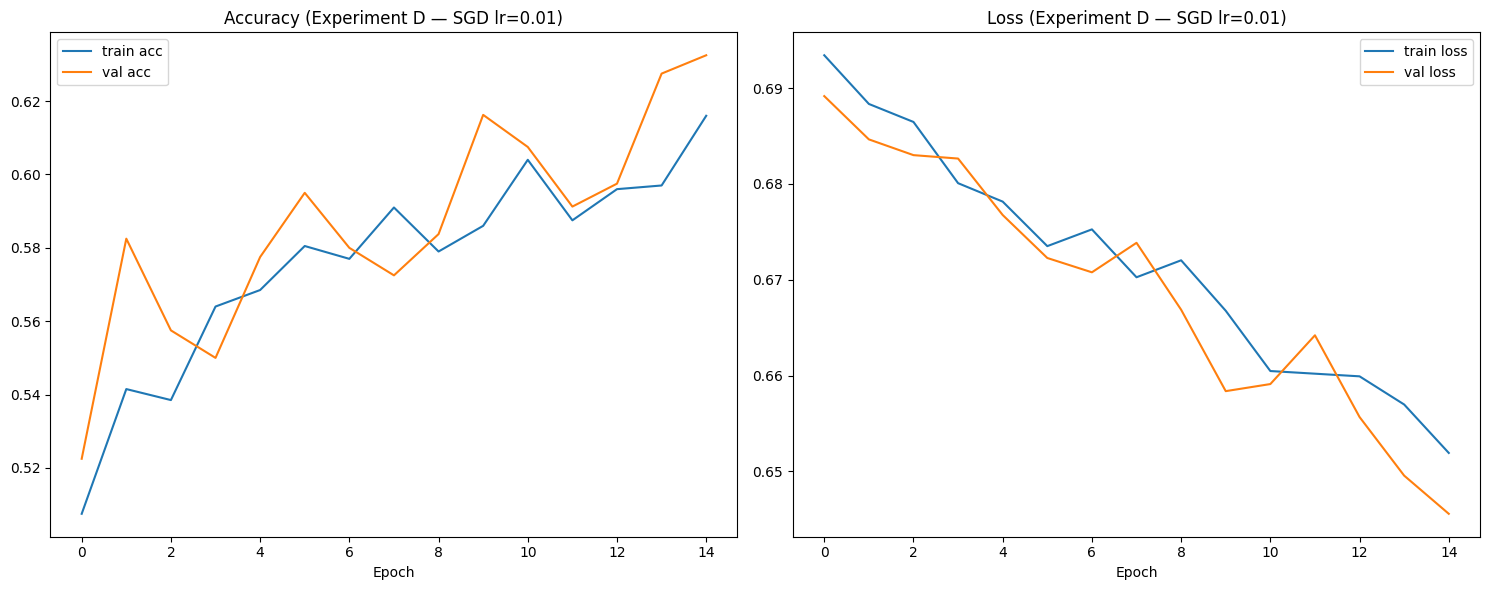

In [12]:
def build_model_D():
    
    return Baseline_model()

model_D = build_model_D()
model_D.compile(
    optimizer=keras.optimizers.SGD(learning_rate=0.01),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
history_D = model_D.fit(train_generator, epochs=EPOCHS,
                        validation_data=val_generator)
plot_history(history_D, title='(Experiment D — SGD lr=0.01)')



Epoch 1/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 43s 644ms/step - accuracy: 0.5320 - loss: 0.6945 - val_accuracy: 0.5050 - val_loss: 0.6944
Epoch 2/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 39s 622ms/step - accuracy: 0.5395 - loss: 0.6879 - val_accuracy: 0.5675 - val_loss: 0.6746
Epoch 3/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 39s 620ms/step - accuracy: 0.5820 - loss: 0.6716 - val_accuracy: 0.5400 - val_loss: 0.6730
Epoch 4/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 39s 619ms/step - accuracy: 0.5855 - loss: 0.6734 - val_accuracy: 0.5962 - val_loss: 0.6711
Epoch 5/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 40s 638ms/step - accuracy: 0.5970 - loss: 0.6682 - val_accuracy: 0.5863 - val_loss: 0.6538
Epoch 6/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 39s 610ms/step - accuracy: 0.6610 - loss: 0.6155 - val_accuracy: 0.6612 - val_loss: 0.6047
Epoch 7/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 40s 633ms/step - accuracy: 0.6425 - loss: 0.6327 - val_accuracy: 0.6700 - val_loss: 0.6054
Epoch 8/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 39s 615ms/step - accuracy: 0.6470 - loss: 0.6298 - val_accu

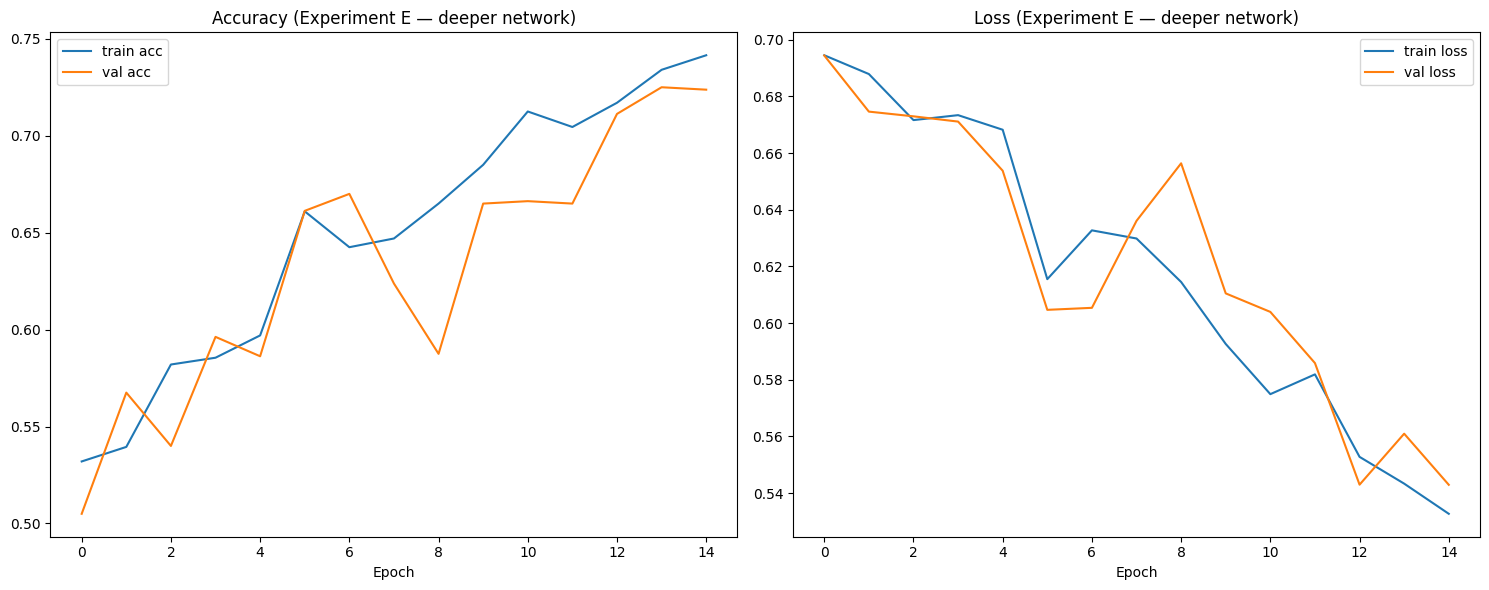

In [13]:
def build_model_E():
    model = keras.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu',
                      input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
        layers.MaxPooling2D(2, 2),

        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D(2, 2),

        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.MaxPooling2D(2, 2),

        # NEW block
        layers.Conv2D(256, (3, 3), activation='relu'),
        layers.MaxPooling2D(2, 2),

        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')
    ])
    return model

model_E = build_model_E()
model_E.compile(optimizer='adam', loss='binary_crossentropy',
                metrics=['accuracy'])
history_E = model_E.fit(train_generator, epochs=EPOCHS,
                        validation_data=val_generator)
plot_history(history_E, title='(Experiment E — deeper network)')


In [17]:
models=[model,model_A, model_B, model_C, model_D, model_E]
for mod in models:
    mod.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,485,445 (55.26 MB)

 Trainable params: 4,828,481 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 15, 15, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │     3,211,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,800,581 (41.20 MB)

 Trainable params: 3,600,193 (13.73 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 7,200,388 (27.47 MB)

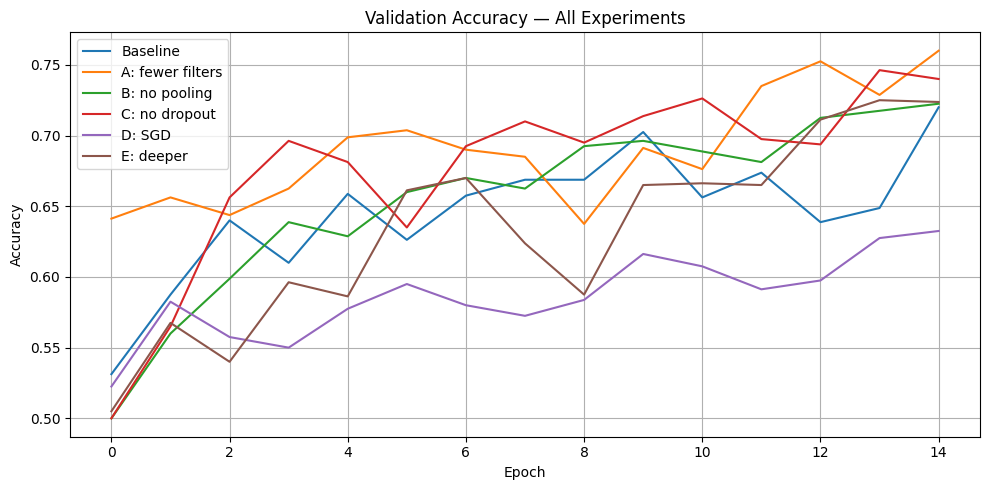

In [19]:
all_histories = {
    'Baseline': history,
    'A: fewer filters': history_A,
    'B: no pooling': history_B,
    'C: no dropout': history_C,
    'D: SGD': history_D,
    'E: deeper': history_E,
}

plt.figure(figsize=(10, 5))
for name, h in all_histories.items():
    plt.plot(h.history['val_accuracy'], label=name)
plt.title('Validation Accuracy — All Experiments')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
